In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/v_books.csv')

In [ ]:
df.head(5)

,isbn,book_title,book_author,year_of_publication,publisher,image_url_m,book_rating,user_id,age,city,state,country
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,<NA>,2,18,stockton,california,usa
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,5,8,<NA>,timmins,ontario,canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,<NA>,8,<NA>,timmins,ontario,canada
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,<NA>,8,<NA>,timmins,ontario,canada
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,<NA>,8,<NA>,timmins,ontario,canada


In [ ]:
df.shape

(1042536, 12)

In [ ]:
df.isnull().sum()

,0
isbn,0
book_title,0
book_author,0
year_of_publication,14188
publisher,0
image_url_m,0
book-rating,0
user_id,0
age,286005
city,437


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1042536 entries, 0 to 1042535
Data columns (total 12 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   isbn                 1042536 non-null  object 
 1   book_title           1042536 non-null  object 
 2   book_author          1042536 non-null  object 
 3   year_of_publication  1028348 non-null  float64
 4   publisher            1042536 non-null  object 
 5   image_url_m          1042536 non-null  object 
 6   book-rating          1042536 non-null  int64  
 7   user_id              1042536 non-null  int64  
 8   age                  756531 non-null   float64
 9   city                 1042099 non-null  object 
 10  state                1001235 non-null  object 
 11  country              1006494 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 95.4+ MB


In [ ]:
df['year_of_publication'] = df['year_of_publication'].astype('Int64')

In [ ]:
df['age'] = df['age'].astype('Int64')

In [ ]:
df['book_rating'] = df['book_rating'].astype('Int64')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1042536 entries, 0 to 1042535
Data columns (total 12 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   isbn                 1042536 non-null  object 
 1   book_title           1042536 non-null  object 
 2   book_author          1042536 non-null  object 
 3   year_of_publication  1028348 non-null  Int64  
 4   publisher            1042536 non-null  object 
 5   image_url_m          1042536 non-null  object 
 6   book_rating          388327 non-null   float64
 7   user_id              1042536 non-null  int64  
 8   age                  756531 non-null   Int64  
 9   city                 1042099 non-null  object 
 10  state                1001235 non-null  object 
 11  country              1006494 non-null  object 
dtypes: Int64(2), float64(1), int64(1), object(8)
memory usage: 97.4+ MB


In [ ]:
# changing book ratings to null, wherever it is 0 so it doesnot ness with the avg.

df['book-rating'] = df['book-rating'].replace(0,pd.NA)

In [ ]:
df["book-rating"].isna().sum()


np.int64(654209)

In [ ]:
# checking duplicates (ps. no duplicates wow)

df.duplicated().sum()


np.int64(0)

In [ ]:
df.rename(columns={'book-rating': 'book_rating'}, inplace=True)


In [ ]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing


,0
book_rating,62.751694
age,27.433585
state,3.961590
country,3.457147
year_of_publication,1.360912
city,0.041917
isbn,0.000000
book_title,0.000000
book_author,0.000000
user_id,0.000000


In [ ]:
df["book_rating"] = pd.to_numeric(df["book_rating"], errors="coerce")


<Axes: xlabel='book_rating', ylabel='Count'>

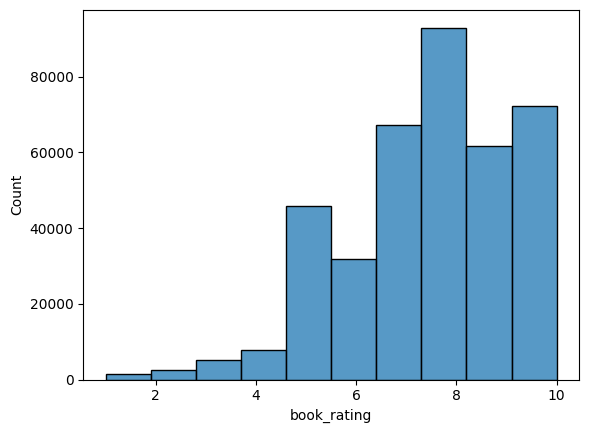

In [ ]:
# rating analysis
df["book_rating"].describe()
sns.histplot(df["book_rating"], bins=10)


In [ ]:
df["book_rating"].value_counts().sort_index()


,count
book_rating,
1,1502
2,2400
3,5175
4,7707
5,45732
6,31974
7,67115
8,92970
9,61586


In [ ]:
# rating per user

ratings_per_user = df.groupby("user_id")["book_rating"].count()
ratings_per_user.describe()




,book_rating
count,91990.0
mean,4.221405
std,36.171079
min,0.0
25%,0.0
50%,1.0
75%,2.0
max,6986.0


In [ ]:
# book popularity analysis

ratings_per_book = df.groupby("isbn")["book_rating"].count()
ratings_per_book.describe()


,book_rating
count,269294.0
mean,1.442019
std,5.909108
min,0.0
25%,0.0
50%,1.0
75%,1.0
max,707.0


In [ ]:
ratings_per_book.sort_values(ascending=False).head(20)


,book_rating
isbn,
0316666343,707
0971880107,581
0385504209,487
0312195516,383
0060928336,320
059035342x,315
059035342X,315
0142001740,307
0446672211,295


In [ ]:
# avg rating
book_stats = (
    df.groupby("isbn")
      .agg(
          avg_rating=("book_rating","mean"),
          rating_count=("book_rating","count")
      )
      .query("rating_count >= 20")
      .sort_values("avg_rating", ascending=False)
)
book_stats.head(20)


/tmp/ipython-input-2119705126.py:8: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  .query("rating_count >= 20")


,avg_rating,rating_count
isbn,,
0439425220,9.869565,23
0060256656,9.75,20
0618002235,9.72,25
0836218221,9.6,20
0836220889,9.583333,24
0743454529,9.545455,22
0140143505,9.464286,28
0345339738,9.402597,77
0060256672,9.4,25


<Axes: xlabel='year_of_publication', ylabel='Count'>

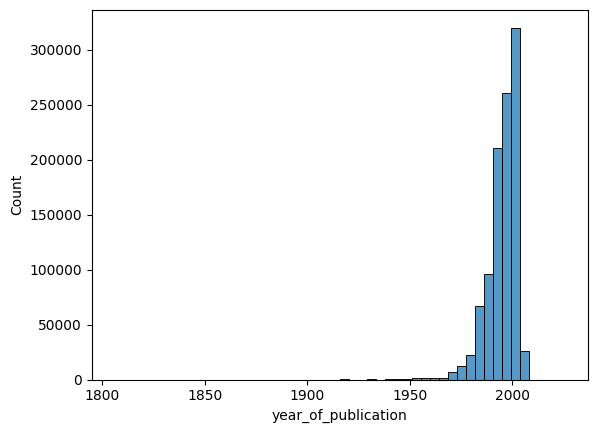

In [ ]:
# time analysis
# books by year
df["year_of_publication"].describe()
sns.histplot(df["year_of_publication"], bins=50)


<Axes: xlabel='year_of_publication', ylabel='book_rating'>

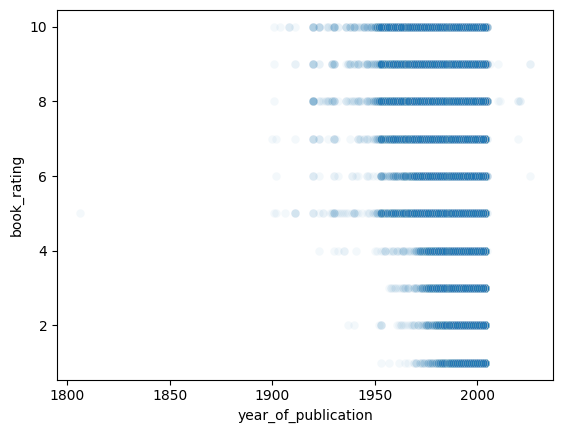

In [ ]:
# rating vs publication
sns.scatterplot(
    data=df,
    x="year_of_publication",
    y="book_rating",
    alpha=0.05
)


In [ ]:
# author analysis
# most "rated" authors

df.groupby("book_author")["book_rating"].count().sort_values(ascending=False).head(20)


,book_rating
book_author,
Stephen King,4751
John Grisham,3085
Nora Roberts,3018
James Patterson,2387
J. K. Rowling,2323
Mary Higgins Clark,1677
Janet Evanovich,1541
Dean R. Koontz,1538
Tom Clancy,1278


In [ ]:
# "best" rated authors
author_stats = (
    df.groupby("book_author")
      .agg(avg_rating=("book_rating","mean"),
           rating_count=("book_rating","count"))
      .query("rating_count >= 30")
      .sort_values("avg_rating", ascending=False)
)
author_stats.head(20)


/tmp/ipython-input-2559883769.py:6: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  .query("rating_count >= 30")


,avg_rating,rating_count
book_author,,
Penny Frank,9.741935,31
Helene Siegel,9.631579,38
Maud Hart Lovelace,9.288462,52
Art Spiegelman,9.24,50
Philip D. Eastman,9.233333,30
Dr. Seuss,9.1875,240
Bill Watterson,9.186186,333
Juliet Marillier,9.166667,42
Shel Silverstein,9.15873,126


In [ ]:
# publisher analysis
# top rated publishers
publisher_stats = (
    df.groupby("publisher")
      .agg(avg_rating=("book_rating","mean"),
           rating_count=("book_rating","count"))
      .query("rating_count >= 50")
      .sort_values("rating_count", ascending=False)
)
publisher_stats.head(20)


/tmp/ipython-input-881447009.py:6: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  .query("rating_count >= 50")


,avg_rating,rating_count
publisher,,
Ballantine Books,7.611133,12899
Pocket,7.5651,10699
Berkley Publishing Group,7.441905,9493
Warner Books,7.534581,9297
Bantam,7.799462,7440
Bantam Books,7.519804,7347
Penguin Books,7.770675,7086
Signet Book,7.591292,6775
Perennial,7.812203,5884


In [ ]:
# geo analysis
df["country"].value_counts().head(20)


,count
country,
usa,754231
canada,93970
unitedkingdom,32152
germany,27766
australia,18318
spain,14775
france,10635
portugal,6933
newzealand,5605


In [ ]:
# rating by country
country_stats = (
    df.groupby("country")
      .agg(avg_rating=("book_rating","mean"),
           rating_count=("book_rating","count"))
      .query("rating_count >= 100")
      .sort_values("avg_rating", ascending=False)
)
country_stats.head(20)


/tmp/ipython-input-2120425600.py:6: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  .query("rating_count >= 100")


,avg_rating,rating_count
country,,
romania,9.158562,473
dominicanrepublic,8.822917,384
iran,8.630137,438
england,7.911765,340
philippines,7.904676,556
poland,7.89172,157
china,7.781646,316
brazil,7.777011,435
portugal,7.773908,3388


(5.0, 100.0)

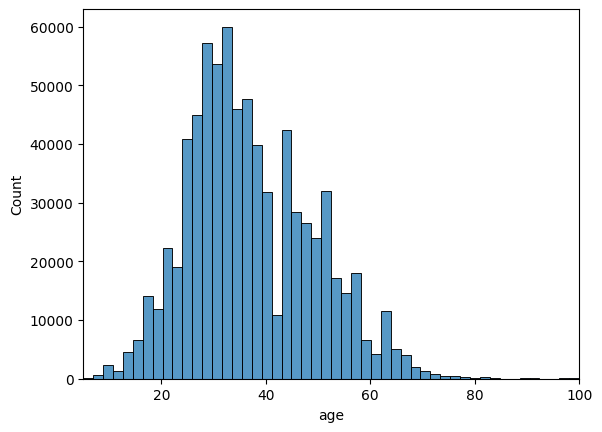

In [ ]:
# age analysis
# age distribution

sns.histplot(df["age"], bins=50)
plt.xlim(5,100)


<Axes: xlabel='age_group', ylabel='book_rating'>

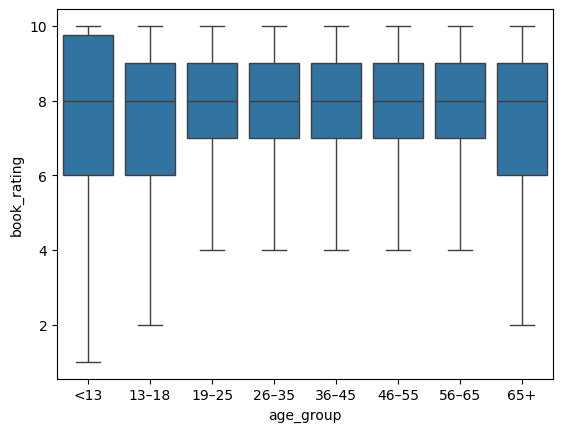

In [ ]:
# rating vs age
age_bins = [0, 12, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['<13', '13–18', '19–25', '26–35', '36–45', '46–55', '56–65', '65+']

df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

sns.boxplot(
    x='age_group',
    y='book_rating',
    data=df,
    showfliers=False
)



<Axes: xlabel='rating_count', ylabel='avg_rating'>

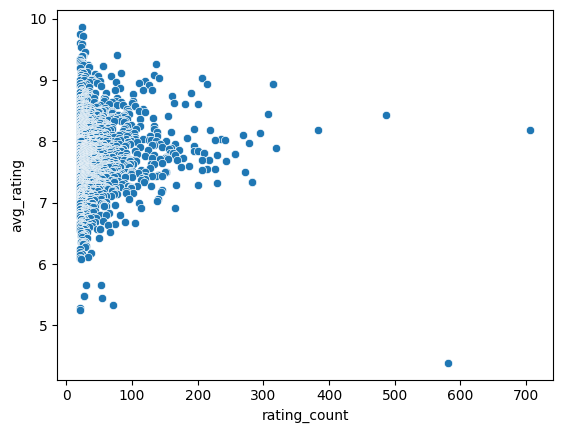

In [ ]:
# Popular ≠ well rated?

sns.scatterplot(
    x=book_stats["rating_count"],
    y=book_stats["avg_rating"]
)


In [ ]:
# insights :
'''

avg book rating is 8 (92k),
avg reader leaves about 4 book ratings,
book with the most ratings (count) is 707,
book with the highest avg rating (9.86) has 23 rating_count,
the trend of books started rising in the second half of the 20th century,
most books were released in early 2000s,
author with the "most number" of ratings is stephen king,
"best"  rated author is penny frank, with an avg rating of 9.7,
publisher with the highest average rating count is ballantine books with avg rating of 7.6,
country with the most published books is usa (754k),
country with the highest avg rating is romania (9.1),
most book readers are in the age bracket of 20-40, followed by 40-60,
books for readers under 13 are the highest rated books on average, from 6 to 9.8,
the age group of 13-18 rate the books from 6 to 9,

'''




np.float64(0.36761680542455455)

In [ ]:
df.to_csv('Books_Final.csv')